In [ ]:
#tis is the part where we import
import numpy as np
import matplotlib.pyplot as plt
import qutip as q
from scipy.special import erfc
from scipy.optimize import brentq


In [ ]:
# ================= 이론식 정책 (beta* = -a/m) =================
# DP 와 같은 backward induction 을 돌리되, beta 를 후보 중에서 고르지 않고
# 공식으로 바로 계산한다. dolinar_update 와 dolinar_update_theory 를
# 나란히 놓고 보면 차이는 argmin 한 줄뿐이다.

def _auto_n_lam(alpha, N, per_step=10, hard_cap=400001):
    """슬롯당 lam 이동량(~4a^2)을 per_step 개로 쪼갤 만큼의 격자점 수.
    이보다 성기면 갱신이 격자 간격에 묻혀 값이 조용히 틀려진다."""
    a2 = alpha**2 / N
    lam_max = max(12.0, 6.0 * alpha**2 + 12.0)
    n = int(2 * lam_max * per_step / (4 * a2)) + 1
    return int(np.clip(n, 601, hard_cap))


def beta_theory(lam, a, bmax=np.inf):
    """이론식 beta* = -a/m,  m = tanh(lam/2).
    bmax 를 주면 거기서 자른다. m=0 에서 발산하므로 캡이 없으면 락업된다."""
    m = np.tanh(lam / 2)
    m = np.where(np.abs(m) < 1e-12, 1e-12, m)
    return np.clip(-a / m, -bmax, bmax)


def dolinar_update_theory(V, lam, a, beta):
    """벨만 1스텝, 단 최소화 없음.  beta 는 (n_lam,) — 믿음마다 이미 정해져 있음.

        V_k(lam) = sum_o  P(o) * V_{k-1}(lam')      <- min_beta 가 없다
    """
    p = _sigmoid(lam)
    mu_p = ( a + beta) ** 2 + 1e-300           # (n_lam,)
    mu_m = (-a + beta) ** 2 + 1e-300

    tot = 0.0                                  # (n_lam,) 배열
    for o in (0, 1):
        L_p = L_analytic(mu_p, o)
        L_m = L_analytic(mu_m, o)
        nxt = lam + np.log(L_p + 1e-300) - np.log(L_m + 1e-300)
        tot = tot + (p * L_p + (1 - p) * L_m) * np.interp(nxt, lam, V)

    return tot, beta                           # DP 는 여기서 argmin 을 했다


def dolinar_error_theory(alpha, N, n_lam=None, cap=True,
                         per_step=10, return_policy=False):
    """이론식 정책의 오류확률. dolinar_error 와 같은 구조.

    cap=False 로 두면 m=0 에서 beta 가 발산해 첫 슬롯이 정보를 못 주고
    Pe = 0.5 에 락업된다. 발산이 왜 문제인지 직접 확인할 수 있다.
    """
    if alpha <= 0:
        return (0.5, None) if return_policy else 0.5
    if n_lam is None:
        n_lam = _auto_n_lam(alpha, N, per_step)

    a    = alpha / np.sqrt(N)                  #a is Nth division for alpha
    lam  = _lam_grid(alpha, n_lam)             # lam 
    bmax = beta_opt(a) if cap else np.inf      # cell 2 의 단발 최적 변위
    beta = beta_theory(lam, a, bmax)           # 제어: 격자 대신 공식

    p = _sigmoid(lam)
    V = np.minimum(p, 1 - p)                   # k = 0 : 그냥 찍기
    policy = []
    for _ in range(N):                         # 남은 슬롯 1개 -> N개
        V, beta_star = dolinar_update_theory(V, lam, a, beta)
        policy.append(beta_star)

    pe = float(np.interp(0.0, lam, V))         # 사전확률 50:50 -> lam = 0
    return (pe, (lam, policy)) if return_policy else pe



In [9]:
def error_ke(N,alpha_ke,beta_ke=None):
    if beta_ke == None:
        beta_ke=alpha_ke
    a_p=q.coherent(N,alpha_ke) #a_p is positive alpha
    a_n=q.coherent(N,-alpha_ke) #a_n is negative alpha
    #displacement operator
    D_beta = q.displace(N, beta_ke)
    a_dp= D_beta*a_p
    a_dn= D_beta*a_n
    p_dp = abs(a_dp.full()[0][0])**2
    p_dn = abs(a_dn.full()[0][0])**2
    
    return p_dp / 2 + (1 - p_dn) / 2
    

def beta_opt(a):
    if a > 3.0:                       # b* - a < 1 ULP, 구분 불가
        return a
    g = lambda b: 4*a*b - np.log((b + a)/(b - a))
    lo = np.nextafter(a, np.inf)      # 표현 가능한 a 바로 다음 수
    return brentq(g, lo, 3*a + 1)


In [26]:
alphas=np.linspace(0,2,200)

# 2. Ideal Kennedy
P_kennedy = 0.5 * np.exp(-4 * np.abs(alphas)**2)

# 3. Helstrom bound
overlap_squared = np.exp(-4 * np.abs(alphas)**2)
P_helstrom = 0.5 * (1 - np.sqrt(1 - overlap_squared))

#optimal kennedy
P_kennedy_opt=[error_ke(30,i,beta_opt(i)) for i in alphas]

#homodyne
P_hom_theory = 0.5 * erfc(np.sqrt(2) * np.abs(alphas))

#dolinar reciever
P_dolinar = np.array([dolinar_error_theory(al, 400) for al in alphas])



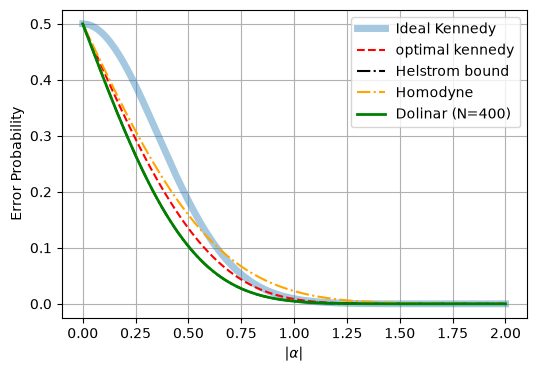

In [28]:
# --- Simplest Plot Structure ---
fig, ax = plt.subplots(figsize=(6, 4))

# 투명도(alpha=0.4)와 두께(linewidth=5)를 줘서 바탕에 깔아줌
ax.plot(alphas, P_kennedy, label="Ideal Kennedy", linewidth=5, alpha=0.4)

# 그 위에 얇은 점선('--')을 얹어서 두 그래프가 겹쳐서 같이 간다는 걸 증명
ax.plot(alphas,P_kennedy_opt , '--', label="optimal kennedy", color='red')

# 헬스트롬 바운드
ax.plot(alphas, P_helstrom, '-.', label="Helstrom bound", color='black')

#호모다인
ax.plot(alphas, P_hom_theory, '-.', label="Homodyne", color='orange')

#돌리너 리시버
ax.plot(alphas, P_dolinar, label="Dolinar (N=400)", color='green', lw=2)

#ax.set_yscale('log')   # 이거 없으면 세 곡선이 다 붙어 보임
ax.set_xlabel(r"$|\alpha|$")
ax.set_ylabel("Error Probability")
ax.grid(True)
ax.legend()

plt.show()

In [ ]:
#optimal version of dolinar (작은 수 최적화 된 버전)

# ================= 우도 =================
def L_analytic(mu, o):
    """평균 광자수 mu 일 때 관측 o 의 우도.
    o = 0 침묵 -> exp(-mu),  o = 1 클릭 -> 1 - exp(-mu)"""
    return (np.exp(-mu), -np.expm1(-mu))[o]

# ================= 격자 위 정확한 DP =================
def _beta_grid(a, n_s=150):
    """변위 후보. |beta| >= a 이고, s = |beta| - a 를 0 부터 기하적으로 배치.
    s = 0 이 완전 nulling 이라 큰 alpha 에서 이 점이 격자에 반드시 있어야 함."""
    s = np.concatenate([[0.0], np.geomspace(1e-9, 2.5, n_s)])
    return np.concatenate([-(a + s), (a + s)])

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def _lam_grid(alpha, n_lam=601):
    """믿음 축. lam_max 는 큰 alpha 에서 확신이 세지는 걸 덮을 만큼."""
    lam_max = max(12.0, 6.0 * alpha ** 2 + 12.0)
    return np.linspace(-lam_max, lam_max, n_lam)


def dolinar_update(V, lam, a, beta):
    """벨만 1스텝.  V = V_{k-1} 을 받아 (V_k, 그때의 최적 beta(lam)) 를 돌려줌.

        V_k(lam) = min_beta  sum_o  P(o) * V_{k-1}(lam')
        P(o)  = p L+ + (1-p) L-          그 관측이 나올 예측확률
        lam'  = lam + log L+ - log L-    베이즈 갱신
    """
    p = _sigmoid(lam)
    P, LAM = p[:, None], lam[:, None]          # 믿음 축  (n_lam, 1)
    B = beta[None, :]                          # 제어 축  (1, n_beta)
    mu_p = ( a + B) ** 2 + 1e-300
    mu_m = (-a + B) ** 2 + 1e-300

    tot = 0.0                                  # (n_lam, n_beta) 표
    for o in (0, 1):
        L_p = L_analytic(mu_p, o)
        L_m = L_analytic(mu_m, o)
        nxt = LAM + np.log(L_p + 1e-300) - np.log(L_m + 1e-300)
        tot = tot + (P * L_p + (1 - P) * L_m) * np.interp(nxt, lam, V)

    j = tot.argmin(axis=1)                     # 믿음마다 최적 제어를 고름
    return tot[np.arange(lam.size), j], beta[j]


def dolinar_error_sopt(alpha, N, n_lam=601, n_s=150, return_policy=False):
    """backward induction 으로 오류확률을 직접 계산.
    V_k(lam) = k 슬롯 남았을 때 도달 가능한 최소 오류확률."""
    if alpha <= 0:
        return (0.5, None) if return_policy else 0.5

    a    = alpha / np.sqrt(N)                  # 슬롯당 진폭 (에너지 보존)
    lam  = _lam_grid(alpha, n_lam)             # 믿음 축
    beta = _beta_grid(a, n_s)                  # 제어 축

    p = _sigmoid(lam)
    V = np.minimum(p, 1 - p)                   # k = 0 : 그냥 찍기
    policy = []
    for _ in range(N):                         # 남은 슬롯 1개 -> N개
        V, beta_star = dolinar_update(V, lam, a, beta)
        policy.append(beta_star)               # policy[k-1] = k 슬롯 남았을 때

    pe = float(np.interp(0.0, lam, V))         # 사전확률 50:50 -> lam = 0
    return (pe, (lam, policy)) if return_policy else pe